In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import unicodedata

from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import Ridge
from sklearn.ensemble import VotingRegressor
from sklearn.compose import TransformedTargetRegressor
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, RegressorMixin, clone
from sklearn.utils._tags import RegressorTags
from lightgbm import LGBMRegressor

from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor


def _regressor_tags_compat(self):
    tags = BaseEstimator.__sklearn_tags__(self)
    tags.estimator_type = "regressor"
    tags.regressor_tags = RegressorTags()
    tags.target_tags.required = True
    return tags


RegressorMixin.__sklearn_tags__ = _regressor_tags_compat

In [84]:
df = pd.read_csv('database/test.csv')
#df = pd.read_csv('database/train_mod.csv')
df.head()

,ID,Débitos,Fabricante,Modelo,Ano,Categoria,Couro,Combustivel,Volume_motor,Km,...,Airbags,Preco,Numero_proprietarios,Data_ultima_lavagem,Adesivos_personalizados,Radio_AM_FM,Historico_troca_oleo,Codigo_concessionaria,Classificacao_Veiculo,Faixa_Preco
0,45804429,1017,HYUNDAI,Tucson,2017,SUV,Sim,Dies.,2,48089 km,...,4,40556.0,5,2022-11-19,Não,FM,8,4776,Usado,Médio
1,45768909,-,MERCEDES-BENZ,C 180,1995,Sedan,Nao,gasolina,1.8 Turbo,NaN,...,2,5331.0,2,2021-09-30,Sim,FM,1,7983,Usado,Econômico
2,45788796,836,BMW,118,2010,Sedan,Sim,Diesel,2,197000 km,...,0,18817.0,5,2021-05-08,Sim,AM,6,2664,Usado,Econômico
3,42974578,891,KIA,Sportage SX,2016,SUV,Sim,Gasolina,2.0 Turbo,55447 km,...,10,22894.0,5,2021-06-11,Não,FM,5,8234,Usado,Médio
4,45801622,583,HYUNDAI,Elantra,2011,Sedan,Sim,Gasolina,1.6,106616 km,...,4,20005.0,1,2021-12-05,Sim,AM,1,5769,Usado,Médio


In [85]:
df.columns.tolist()

['ID',
 'Débitos',
 'Fabricante',
 'Modelo',
 'Ano',
 'Categoria',
 'Couro',
 'Combustivel',
 'Volume_motor',
 'Km',
 'Cilindros',
 'Tipo_cambio',
 'Tração',
 'Portas',
 'Rodas',
 'Cor',
 'Airbags',
 'Preco',
 'Numero_proprietarios',
 'Data_ultima_lavagem',
 'Adesivos_personalizados',
 'Radio_AM_FM',
 'Historico_troca_oleo',
 'Codigo_concessionaria',
 'Classificacao_Veiculo',
 'Faixa_Preco']

### Coluna ID excluída pois são valores aleatórios

In [86]:
#colunas_excluir = ["Data_ultima_lavagem", "ID", "Faixa_Preco", "Codigo_concessionaria", "Classificacao_Veiculo"]
colunas_excluir = ["ID"]
df = df.drop(columns=colunas_excluir, errors="ignore")

### Coluna Débitos

In [87]:
df["Débitos"] = pd.to_numeric(
    df["Débitos"].replace("-", np.nan),
    errors="coerce"
)

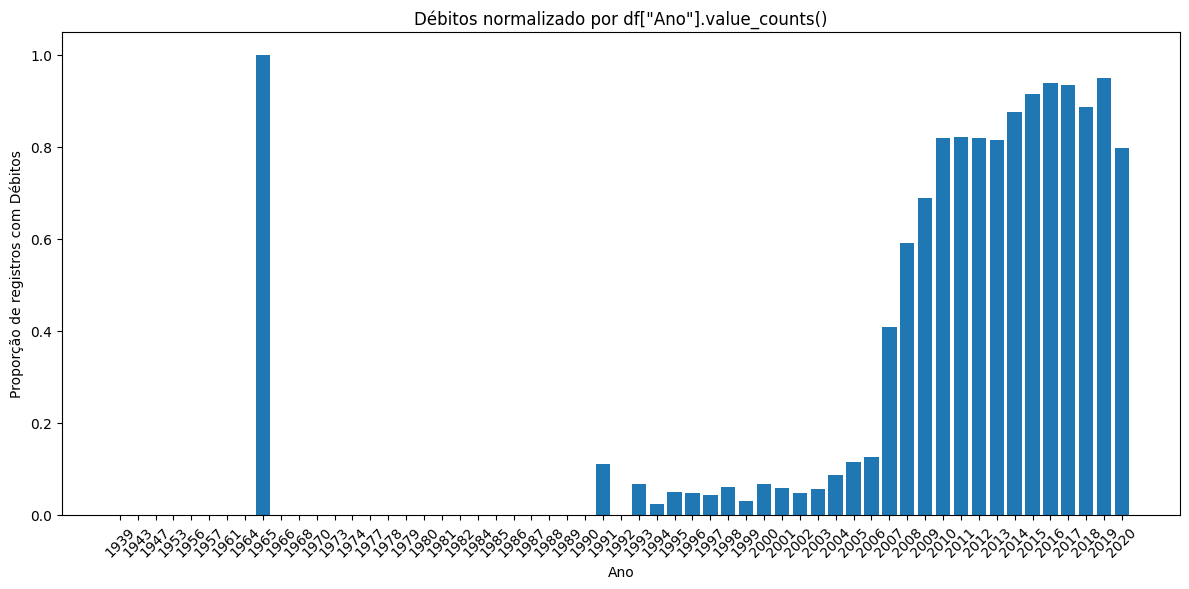

In [88]:
df["Ano"] = pd.to_numeric(df["Ano"], errors="coerce")

# Total de registros por ano
total_por_ano = df["Ano"].value_counts().sort_index()

# Quantidade de registros com Débitos válidos por ano
com_debito_por_ano = df.dropna(subset=["Ano", "Débitos"])["Ano"].value_counts().sort_index()

# Normalização pela contagem total de registros do ano
normalizado = (com_debito_por_ano / total_por_ano).fillna(0).sort_index()

graf = normalizado.reset_index()
graf.columns = ["Ano", "Proporcao_com_Debito"]

plt.figure(figsize=(12, 6))
plt.bar(graf["Ano"].astype(int).astype(str), graf["Proporcao_com_Debito"])
plt.xlabel("Ano")
plt.ylabel("Proporção de registros com Débitos")
plt.title('Débitos normalizado por df["Ano"].value_counts()')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [89]:
df['Débitos'] = df['Débitos'].fillna(0)
df['Débitos'].isna().sum()

0

### Coluna Fabricante

In [90]:
df["Fabricante"].value_counts()

Fabricante
TOYOTA           3295
HYUNDAI          2954
MERCEDES-BENZ    1967
FORD             1044
CHEVROLET         969
                 ... 
TATA                1
TESLA               1
FOTON               1
MG                  1
BENTLEY             1
Name: count, Length: 65, dtype: int64

In [91]:
df["Fabricante"].isna().sum()

0

### Coluna Modelo

In [92]:
df["Modelo"].value_counts()

Modelo
Prius             991
Camry             847
Elantra           826
E 350             560
Sonata            499
                 ... 
Crafter             1
C 250 1.8           1
Megane 1.9 CDI      1
XK                  1
528 F10             1
Name: count, Length: 1499, dtype: int64

In [93]:
df["Modelo"].isna().sum()

0

### Coluna Ano

In [94]:
df["Ano"].value_counts()

Ano
2012    2022
2014    1857
2013    1845
2011    1536
2010    1351
2015    1301
2016    1208
2017     866
2008     715
2009     580
2018     432
2007     431
2005     368
2003     325
2004     304
2006     280
2019     277
2001     242
2000     240
2002     231
1999     203
1998     182
1997     140
1996     107
1995      80
2020      59
1994      44
1993      30
1992      26
1990      21
1988      10
1987       9
1991       9
1986       5
1989       4
1939       3
1985       3
1980       2
1968       2
1981       2
1953       2
1970       1
1966       1
1956       1
1943       1
1979       1
1961       1
1974       1
1965       1
1973       1
1977       1
1982       1
1957       1
1978       1
1947       1
1964       1
1984       1
Name: count, dtype: int64

In [95]:
df["Ano"].isna().sum()

0

### Coluna Categoria

In [96]:
df["Categoria"].value_counts()

Categoria
Sedan             7632
SUV               5130
Hatchback         2612
Minivan            588
Cupê               475
Universal          343
Microonibus        300
Vagao de carga     191
Picape              47
Conversivel         43
Limousine            9
Name: count, dtype: int64

In [97]:
df["Categoria"].isna().sum()

0

### Coluna Couro

In [98]:
df["Couro"].value_counts()

Couro
Sim    12529
Nao     4841
Name: count, dtype: int64

In [99]:
df["Couro"].isna().sum()

0

### Coluna Combustivel

In [100]:
df["Combustivel"].value_counts()

Combustivel
Gasolina       3701
Hibrido        3379
GASOLINA       2338
Gasol.         1923
gasolina       1628
Diesel         1557
DIESEL          942
Dies.           775
diesel          658
Gás Natural     469
Name: count, dtype: int64

In [101]:
def normalizar_texto(texto):
    if pd.isna(texto):
        return texto
    
    texto = str(texto).strip().lower()
    
    # remove acentos
    texto = ''.join(
        c for c in unicodedata.normalize('NFD', texto)
        if unicodedata.category(c) != 'Mn'
    )
    
    return texto

mapeamento = {
    "gasolina": "Gasolina",
    "gasol.": "Gasolina",
    "diesel": "Diesel",
    "dies.": "Diesel",
    "hibrido": "Híbrido",
    "gas natural": "Gás Natural",
    "GASOLINA": "Gasolina",
}

df["Combustivel"] = (
    df["Combustivel"]
    .apply(normalizar_texto)
    .map(mapeamento)
    .fillna(df["Combustivel"])
)

In [102]:
df["Combustivel"].value_counts()

Combustivel
Gasolina       9590
Diesel         3932
Híbrido        3379
Gás Natural     469
Name: count, dtype: int64

In [103]:
df["Combustivel"].isna().sum()

0

### Coluna Volume_motor

In [104]:
df["Volume_motor"].value_counts()

Volume_motor
2            3120
2.5          2060
1.8          1645
1.6          1320
1.5          1234
             ... 
0.8 Turbo       1
5.7 Turbo       1
10.8            1
6.0 Turbo       1
2.6 Turbo       1
Name: count, Length: 107, dtype: int64

In [105]:
df["Volume_motor"] = (
    df["Volume_motor"]
    .astype(str)
    .str.strip()
    .str.replace(",", ".", regex=False)
    .str.extract(r"(\d+(?:\.\d+)?)")[0]
)

df["Volume_motor"] = pd.to_numeric(df["Volume_motor"], errors="coerce")

In [106]:
df["Volume_motor"].value_counts()

Volume_motor
2.0     3529
2.5     2148
1.8     1803
1.6     1442
1.5     1297
        ... 
6.4        2
5.8        1
6.6        1
0.3        1
10.8       1
Name: count, Length: 65, dtype: int64

In [107]:
df["Volume_motor"].isna().sum()

0

### Coluna Km

In [108]:
df["Km"].value_counts()

Km
0 km         583
200000 km    149
150000 km    127
180000 km    106
100000 km     94
            ... 
248570 km      1
13048 km       1
31381 km       1
27176 km       1
146697 km      1
Name: count, Length: 6377, dtype: int64

In [109]:
df["Km"] = (
    df["Km"]
    .astype(str)
    .str.replace(" km", "", regex=False)
    .str.replace(".", "", regex=False)
    .str.strip()
)

df["Km"] = pd.to_numeric(df["Km"], errors="coerce")

In [110]:
df["Km"].value_counts()

Km
0.0         583
200000.0    149
150000.0    127
180000.0    106
100000.0     94
           ... 
248570.0      1
13048.0       1
31381.0       1
27176.0       1
146697.0      1
Name: count, Length: 6377, dtype: int64

In [111]:
df['Km'].isna().sum()

1735

In [112]:
df.sort_values("Km")

,Débitos,Fabricante,Modelo,Ano,Categoria,Couro,Combustivel,Volume_motor,Km,Cilindros,...,Airbags,Preco,Numero_proprietarios,Data_ultima_lavagem,Adesivos_personalizados,Radio_AM_FM,Historico_troca_oleo,Codigo_concessionaria,Classificacao_Veiculo,Faixa_Preco
13265,915.0,BMW,X5,2014,SUV,Sim,Diesel,3.0,0.0,6,...,0,NaN,5,2022-06-20,Não,AM,10,4443,Usado,NaN
8552,0.0,TOYOTA,Prius,2005,Sedan,Nao,Gasolina,1.5,0.0,4,...,6,9408.0,5,2020-07-30,Sim,AM/FM,1,4722,Usado,Econômico
637,1051.0,HYUNDAI,Sonata,2016,Sedan,Nao,Gasolina,2.4,0.0,4,...,0,16935.0,2,2020-09-15,Não,FM,7,3821,Usado,Econômico
13967,0.0,ISUZU,Trooper,1999,SUV,Sim,Gás Natural,3.5,0.0,6,...,2,NaN,4,2022-01-09,Sim,FM,9,9893,Usado,NaN
8565,1055.0,FORD,Explorer,2013,SUV,Sim,Gasolina,3.5,0.0,6,...,12,6429.0,1,2022-01-14,Não,AM,4,5780,Usado,Econômico
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17342,0.0,AUDI,A7,2012,Sedan,Sim,Gasolina,3.0,NaN,6,...,12,NaN,4,2021-10-28,Não,AM/FM,9,8939,Usado,NaN
17347,640.0,VOLKSWAGEN,Jetta TDI,2013,Sedan,Sim,Diesel,2.0,NaN,4,...,8,NaN,4,2020-07-17,Sim,AM,1,3097,Usado,NaN
17349,781.0,TOYOTA,RAV 4,2012,SUV,Sim,Gasolina,2.5,NaN,12,...,12,NaN,1,2022-04-27,Não,AM/FM,4,8954,Usado,NaN
17358,697.0,MERCEDES-BENZ,C 250,2015,Cupê,Sim,Gasolina,1.8,NaN,4,...,12,NaN,3,2022-07-14,Não,AM/FM,8,6194,Usado,NaN


In [113]:
# Regras adicionais para tratar quilometragens improvaveis antes da modelagem.
# Mantive 2023 como referencia porque o notebook ja usa essa data em Data_ultima_lavagem.
ano_ref = 2023

df["Idade"] = (ano_ref - df["Ano"]).clip(lower=1)
df.loc[(df["Km"] >= 4_000_000.0) | (df["Km"] < 10_000), "Km"] = pd.NA

df["Km_por_ano"] = df["Km"] / df["Idade"]
km_str = df["Km"].round().astype("Int64").astype("string")

padrao_km_repetido = km_str.str.fullmatch(r"(\d)\1{4,}", na=False)
valores_km_sentinela = df["Km"].isin([
    11_111, 22_222, 33_333, 44_444, 55_555, 66_666, 77_777, 88_888, 99_999,
    111_111, 222_222, 333_333, 444_444, 555_555, 666_666, 777_777, 888_888, 999_999,
    1_111_111, 2_222_222, 123_456, 1_234_567, 101_010, 121_212
])

regra_km_suspeito = (
    (df["Km"] >= 1_000_000) |
    (df["Km_por_ano"] > 70_000) |
    ((df["Idade"] >= 2) & (df["Km_por_ano"] < 1_000)) |
    padrao_km_repetido |
    valores_km_sentinela
)

print("Km marcados como ausentes por regras adicionais:", int(regra_km_suspeito.sum()))
df.loc[regra_km_suspeito, "Km"] = pd.NA

df["Km_por_ano"] = df["Km"] / df["Idade"]

Km marcados como ausentes por regras adicionais: 296


In [114]:
df.sort_values("Km")

,Débitos,Fabricante,Modelo,Ano,Categoria,Couro,Combustivel,Volume_motor,Km,Cilindros,...,Numero_proprietarios,Data_ultima_lavagem,Adesivos_personalizados,Radio_AM_FM,Historico_troca_oleo,Codigo_concessionaria,Classificacao_Veiculo,Faixa_Preco,Idade,Km_por_ano
2935,0.0,MERCEDES-BENZ,C 300,2018,Sedan,Sim,Gasolina,2.0,10000.0,4,...,3,2022-02-23,Sim,AM/FM,0,7237,Semi-novo,Luxo,5,2000.000000
7754,0.0,TOYOTA,Aqua,2014,Sedan,Sim,Híbrido,1.5,10000.0,4,...,5,2022-12-09,Não,AM/FM,1,1026,Usado,Econômico,9,1111.111111
2401,697.0,HYUNDAI,Elantra,2015,Sedan,Sim,Gasolina,1.8,10000.0,6,...,5,2022-12-12,Não,AM,6,7810,Usado,NaN,8,1250.000000
2251,873.0,MITSUBISHI,Mirage,2014,Hatchback,Nao,Gasolina,1.0,10000.0,4,...,2,2021-04-12,Não,FM,1,5744,Usado,Econômico,9,1111.111111
4700,639.0,BMW,528,2014,Sedan,Sim,Gasolina,2.0,10000.0,12,...,3,2022-10-28,Sim,AM/FM,8,8384,Usado,Médio,9,1111.111111
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17349,781.0,TOYOTA,RAV 4,2012,SUV,Sim,Gasolina,2.5,NaN,12,...,1,2022-04-27,Não,AM/FM,4,8954,Usado,NaN,11,NaN
17358,697.0,MERCEDES-BENZ,C 250,2015,Cupê,Sim,Gasolina,1.8,NaN,4,...,3,2022-07-14,Não,AM/FM,8,6194,Usado,NaN,8,NaN
17363,0.0,VOLKSWAGEN,CC,2009,Cupê,Sim,Gasolina,2.0,NaN,6,...,4,2021-12-09,Não,AM/FM,3,4776,Usado,NaN,14,NaN
17367,1646.0,LEXUS,GX 460,2015,SUV,Sim,Gasolina,4.6,NaN,8,...,2,2022-10-17,Não,FM,9,2500,Usado,NaN,8,NaN


### Coluna Cilindros

In [115]:
df["Cilindros"].value_counts()

Cilindros
4      12820
6       3195
8        951
5        165
3        109
2         39
1         36
12        34
10        11
7          4
16         2
127        1
11         1
15         1
9          1
Name: count, dtype: int64

In [116]:
df['Cilindros'].isna().sum()

0

### Coluna Tipo_cambio

In [117]:
df["Tipo_cambio"].value_counts()

Tipo_cambio
Automatico    12084
Tiptronic      2884
Manual         1769
Variator        633
Name: count, dtype: int64

In [118]:
df['Tipo_cambio'].isna().sum()

0

### Coluna Tração

In [119]:
df["Tração"].value_counts()

Tração
Dianteira    11429
4x4           3780
Traseira      2161
Name: count, dtype: int64

In [120]:
df['Tração'].isna().sum()

0

### Coluna Portas

In [121]:
df["Portas"].value_counts()

Portas
4-5    16535
2-3      721
>5       114
Name: count, dtype: int64

In [122]:
df['Portas'].isna().sum()

0

### Coluna Rodas

In [123]:
df["Rodas"].value_counts()

Rodas
32    583
13    577
16    573
22    568
11    568
26    567
21    557
18    553
5     551
14    549
15    548
12    546
10    544
25    540
4     540
7     538
6     538
31    537
8     535
17    535
19    533
1     531
27    531
29    531
3     529
24    527
28    526
30    525
9     525
20    524
23    524
2     517
Name: count, dtype: int64

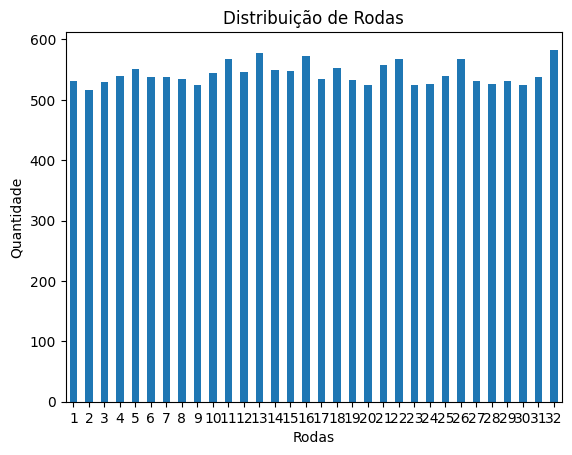

In [124]:
import matplotlib.pyplot as plt

df["Rodas"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Rodas")
plt.ylabel("Quantidade")
plt.title("Distribuição de Rodas")
plt.xticks(rotation=0)
plt.show()

In [125]:
df['Rodas'].isna().sum()

0

In [126]:
## Decidido por excluir a coluna "Rodas" devido a não conseguir entender o significado desse campo.
colunas_excluir = ["Rodas"]
df = df.drop(columns=colunas_excluir, errors="ignore")

### Coluna Cor

In [127]:
df["Cor"].value_counts()

Cor
Preto       4696
Branco      4080
Prata       3240
Cinza       2235
Azul        1336
Red          566
Verde        311
Marrom       174
Vermelho     168
Dourado      135
Bege         120
Azul ceu     114
Amarelo       84
Laranja       60
Roxo          33
Rosa          18
Name: count, dtype: int64

In [128]:
import pandas as pd
import unicodedata

def normalizar_texto(texto):
    if pd.isna(texto):
        return texto
    
    texto = str(texto).strip().lower()
    texto = ''.join(
        c for c in unicodedata.normalize('NFD', texto)
        if unicodedata.category(c) != 'Mn'
    )
    return texto

mapeamento_cor = {
    "preto": "Preto",
    "branco": "Branco",
    "prata": "Prata",
    "cinza": "Cinza",
    "azul": "Azul",
    "azul ceu": "Azul",
    "red": "Vermelho",
    "vermelho": "Vermelho",
    "verde": "Verde",
    "marrom": "Marrom",
    "bege": "Bege",
    "amarelo": "Amarelo",
    "dourado": "Dourado",
    "laranja": "Laranja",
    "roxo": "Roxo",
    "rosa": "Rosa"
}

df["Cor"] = (
    df["Cor"]
    .apply(normalizar_texto)
    .map(mapeamento_cor)
    .fillna(df["Cor"])
)

In [129]:
df["Cor"].value_counts()

Cor
Preto       4696
Branco      4080
Prata       3240
Cinza       2235
Azul        1450
Vermelho     734
Verde        311
Marrom       174
Dourado      135
Bege         120
Amarelo       84
Laranja       60
Roxo          33
Rosa          18
Name: count, dtype: int64

In [130]:
df['Cor'].isna().sum()

0

### Coluna Airbags

In [131]:
df["Airbags"].value_counts()

Airbags
12    5278
4     4844
0     2385
8     1515
6     1166
2      965
10     752
16      94
5       91
7       73
1       72
9       54
11      33
3       29
14      12
13       4
15       3
Name: count, dtype: int64

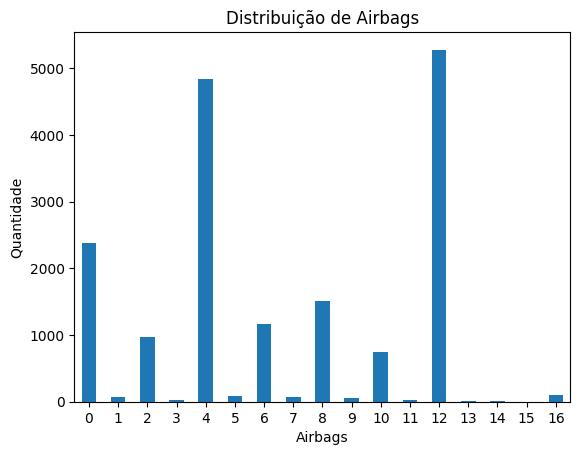

In [132]:
df["Airbags"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Airbags")
plt.ylabel("Quantidade")
plt.title("Distribuição de Airbags")
plt.xticks(rotation=0)
plt.show()

In [133]:
df['Airbags'].isna().sum()

0

### Coluna Preco

In [134]:
df['Preco'].describe()

count    9.090000e+03
mean     2.033085e+04
std      2.766235e+05
min      1.000000e+00
25%      4.861000e+03
50%      1.317200e+04
75%      2.258000e+04
max      2.630750e+07
Name: Preco, dtype: float64

In [135]:
df["Preco"] = pd.to_numeric(df["Preco"], errors="coerce")
df = df.sort_values("Preco", ascending=True)
df.head(8000)

,Débitos,Fabricante,Modelo,Ano,Categoria,Couro,Combustivel,Volume_motor,Km,Cilindros,...,Numero_proprietarios,Data_ultima_lavagem,Adesivos_personalizados,Radio_AM_FM,Historico_troca_oleo,Codigo_concessionaria,Classificacao_Veiculo,Faixa_Preco,Idade,Km_por_ano
7460,1202.0,CHEVROLET,Lacetti,2006,Hatchback,Nao,Gasolina,1.6,200000.0,4,...,2,2020-06-29,Não,AM,3,5846,Usado,Econômico,17,11764.705882
552,900.0,KIA,Sportage,2015,SUV,Nao,Gasolina,2.4,50345.0,4,...,1,2021-02-28,Sim,AM,2,5120,Usado,Econômico,8,6293.125000
5073,697.0,VOLKSWAGEN,Jetta,2015,Sedan,Sim,Gasolina,1.8,65000.0,4,...,3,2022-10-12,Não,FM,10,8218,Usado,Econômico,8,8125.000000
8036,0.0,HYUNDAI,Sonata,2011,Sedan,Sim,Gasolina,2.4,NaN,4,...,2,2022-03-05,Não,AM,5,5641,Usado,Econômico,12,NaN
1647,0.0,CHEVROLET,Cruze,2018,Sedan,Nao,Gasolina,1.4,61000.0,4,...,4,2021-01-24,Sim,AM/FM,7,2619,Semi-novo,Econômico,5,12200.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
605,0.0,BMW,528,2012,Sedan,Sim,Gasolina,2.0,120162.0,4,...,4,2020-04-12,Sim,AM,6,9951,Usado,Médio,11,10923.818182
5313,0.0,MERCEDES-BENZ,ML 350,2011,SUV,Sim,Diesel,3.0,200000.0,6,...,3,2020-11-28,Não,FM,5,1782,Usado,Médio,12,16666.666667
8991,0.0,HYUNDAI,Santa FE,2012,SUV,Sim,Diesel,2.2,NaN,4,...,4,2020-06-02,Não,AM,1,2571,Usado,Médio,11,NaN
85,0.0,BMW,X5,2012,SUV,Sim,Gasolina,4.4,186000.0,8,...,3,2022-05-03,Não,AM,4,2144,Usado,Médio,11,16909.090909


In [136]:
Q1 = df["Preco"].quantile(0.25)
Q3 = df["Preco"].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers_preco = df[(df["Preco"] < limite_inferior) | (df["Preco"] > limite_superior)]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Limite inferior:", limite_inferior)
print("Limite superior:", limite_superior)


Q1: 4861.0
Q3: 22580.0
IQR: 17719.0
Limite inferior: -21717.5
Limite superior: 49158.5


In [137]:
outliers_preco.head(100)

,Débitos,Fabricante,Modelo,Ano,Categoria,Couro,Combustivel,Volume_motor,Km,Cilindros,...,Numero_proprietarios,Data_ultima_lavagem,Adesivos_personalizados,Radio_AM_FM,Historico_troca_oleo,Codigo_concessionaria,Classificacao_Veiculo,Faixa_Preco,Idade,Km_por_ano
6973,891.0,CHEVROLET,Captiva,2016,SUV,Sim,Diesel,2.0,48774.0,4,...,2,2020-02-29,Sim,FM,9,4004,Usado,Médio,7,6967.714286
2912,891.0,BMW,328,2016,Sedan,Sim,Gasolina,2.0,33000.0,4,...,1,2020-01-22,Não,FM,4,7429,Usado,Médio,7,4714.285714
874,1342.0,TOYOTA,Tacoma,2017,SUV,Sim,Gasolina,2.7,94262.0,4,...,5,2020-05-20,Sim,AM,4,2897,Usado,Médio,6,15710.333333
3100,1327.0,TOYOTA,Camry,2018,Sedan,Sim,Gasolina,2.5,22000.0,4,...,4,2020-08-22,Sim,AM/FM,9,7409,Semi-novo,Médio,5,4400.000000
8553,765.0,HYUNDAI,Santa FE,2015,SUV,Sim,Diesel,2.0,121390.0,4,...,1,2020-02-16,Sim,AM/FM,3,9031,Usado,Médio,8,15173.750000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1428,1079.0,HYUNDAI,Sonata,2018,Sedan,Sim,Gasolina,2.0,48605.0,4,...,2,2020-09-09,Sim,AM,4,5763,Semi-novo,Luxo,5,9721.000000
6010,1533.0,CHEVROLET,Impala,2016,Sedan,Sim,Gasolina,3.6,73960.0,4,...,4,2021-01-02,Sim,AM/FM,2,1944,Usado,Luxo,7,10565.714286
2639,1091.0,CHEVROLET,Impala,2016,Sedan,Sim,Gasolina,2.5,80245.0,4,...,2,2020-10-03,Sim,FM,2,8630,Usado,Luxo,7,11463.571429
2596,1091.0,HYUNDAI,H1,2016,Universal,Sim,Diesel,2.5,NaN,4,...,3,2020-07-07,Sim,AM/FM,2,8538,Usado,Luxo,7,NaN


In [138]:
df = df[df["Preco"].notna()].copy()
df.head()

,Débitos,Fabricante,Modelo,Ano,Categoria,Couro,Combustivel,Volume_motor,Km,Cilindros,...,Numero_proprietarios,Data_ultima_lavagem,Adesivos_personalizados,Radio_AM_FM,Historico_troca_oleo,Codigo_concessionaria,Classificacao_Veiculo,Faixa_Preco,Idade,Km_por_ano
7460,1202.0,CHEVROLET,Lacetti,2006,Hatchback,Nao,Gasolina,1.6,200000.0,4,...,2,2020-06-29,Não,AM,3,5846,Usado,Econômico,17,11764.705882
552,900.0,KIA,Sportage,2015,SUV,Nao,Gasolina,2.4,50345.0,4,...,1,2021-02-28,Sim,AM,2,5120,Usado,Econômico,8,6293.125000
5073,697.0,VOLKSWAGEN,Jetta,2015,Sedan,Sim,Gasolina,1.8,65000.0,4,...,3,2022-10-12,Não,FM,10,8218,Usado,Econômico,8,8125.000000
8036,0.0,HYUNDAI,Sonata,2011,Sedan,Sim,Gasolina,2.4,NaN,4,...,2,2022-03-05,Não,AM,5,5641,Usado,Econômico,12,NaN
1647,0.0,CHEVROLET,Cruze,2018,Sedan,Nao,Gasolina,1.4,61000.0,4,...,4,2021-01-24,Sim,AM/FM,7,2619,Semi-novo,Econômico,5,12200.000000


### Coluna Numero_proprietarios

In [139]:
df["Numero_proprietarios"].value_counts()

Numero_proprietarios
5    1855
1    1833
3    1825
4    1796
2    1781
Name: count, dtype: int64

In [140]:
df['Numero_proprietarios'].isna().sum()

0

### Coluna Data_ultima_lavagem

In [141]:
df["Data_ultima_lavagem"].value_counts()

Data_ultima_lavagem
2021-08-10    18
2021-04-08    17
2022-06-15    17
2021-12-16    17
2022-10-08    16
              ..
2022-06-26     2
2021-07-02     2
2022-06-22     2
2020-11-06     2
2020-02-22     1
Name: count, Length: 1097, dtype: int64

In [142]:
df["Data_ultima_lavagem"].astype(str).value_counts().head(30)

Data_ultima_lavagem
2021-08-10    18
2021-04-08    17
2022-06-15    17
2021-12-16    17
2022-10-08    16
2022-07-31    16
2022-05-08    16
2022-05-31    16
2020-05-13    16
2020-03-19    16
2022-09-12    16
2021-09-23    16
2021-11-07    15
2021-09-11    15
2020-01-16    15
2020-11-26    15
2022-11-25    15
2022-01-29    15
2020-11-15    15
2021-04-22    15
2022-10-12    15
2020-11-01    15
2021-10-18    15
2022-04-08    15
2020-09-04    15
2022-04-21    15
2022-08-16    14
2022-10-10    14
2022-08-31    14
2021-06-30    14
Name: count, dtype: int64

In [143]:
df["Data_ultima_lavagem"] = pd.to_datetime(
    df["Data_ultima_lavagem"],
    format="mixed",
    dayfirst=True,
    errors="coerce"
)

In [144]:
# definir a data de referência
data_ref = pd.Timestamp("2023-01-01")

# calcular quantos dias se passaram
df["Dias_desde_ultima_lavagem"] = (data_ref - df["Data_ultima_lavagem"]).dt.days

df[["Data_ultima_lavagem", "Dias_desde_ultima_lavagem"]].head()

,Data_ultima_lavagem,Dias_desde_ultima_lavagem
7460,2020-06-29,916
552,2021-02-28,672
5073,2022-10-12,81
8036,2022-03-05,302
1647,2021-01-24,707


In [145]:
df['Data_ultima_lavagem'].isna().sum()

0

### Coluna Adesivos_personalizados

In [146]:
df["Adesivos_personalizados"].value_counts()

Adesivos_personalizados
Não    4596
Sim    4494
Name: count, dtype: int64

In [147]:
df['Adesivos_personalizados'].isna().sum()

0

### Coluna Radio_AM_FM

In [148]:
df["Radio_AM_FM"].value_counts()

Radio_AM_FM
AM       3097
FM       3031
AM/FM    2962
Name: count, dtype: int64

In [149]:
df['Radio_AM_FM'].isna().sum()

0

### Coluna Historico_troca_oleo

In [150]:
df["Historico_troca_oleo"].value_counts()

Historico_troca_oleo
7     849
9     849
5     842
10    837
4     835
1     830
6     816
0     813
8     808
3     806
2     805
Name: count, dtype: int64

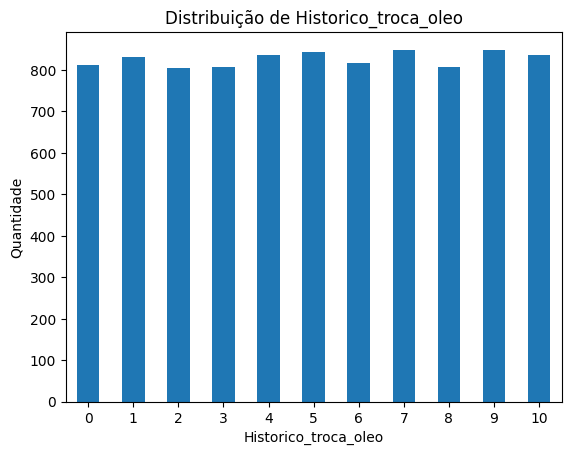

In [151]:
df["Historico_troca_oleo"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Historico_troca_oleo")
plt.ylabel("Quantidade")
plt.title("Distribuição de Historico_troca_oleo")
plt.xticks(rotation=0)
plt.show()

In [152]:
df['Historico_troca_oleo'].isna().sum()

0

### Coluna Codigo_concessionaria

In [153]:
df["Codigo_concessionaria"].value_counts()

Codigo_concessionaria
7647    7
2464    7
2954    6
1218    6
4386    6
       ..
6392    1
1135    1
1628    1
2728    1
2024    1
Name: count, Length: 5713, dtype: int64

In [154]:
colunas_excluir = ["Codigo_concessionaria"]
df = df.drop(columns=colunas_excluir, errors="ignore")

### Coluna Classificacao_Veiculo

In [155]:
df["Classificacao_Veiculo"].value_counts()

Classificacao_Veiculo
Usado        8668
Semi-novo     422
Name: count, dtype: int64

In [156]:
colunas_excluir = ["Classificacao_Veiculo"]
df = df.drop(columns=colunas_excluir, errors="ignore")

### Coluna Faixa_Preco

In [157]:
df["Faixa_Preco"].value_counts()

Faixa_Preco
Econômico     6336
Médio         2289
Luxo           407
Muito Luxo      58
Name: count, dtype: int64

In [158]:
colunas_excluir = ["Faixa_Preco"]
df = df.drop(columns=colunas_excluir, errors="ignore")

### Exportar para excel todos os possíveis valores das colunas

In [159]:
import pandas as pd

lista = []

for col in df.columns:
    vc = df[col].value_counts(dropna=False).reset_index()
    vc.columns = ["valor", "quantidade"]
    vc.insert(0, "coluna", col)
    lista.append(vc)

resultado = pd.concat(lista, ignore_index=True)
resultado.to_excel("value_counts_todas_colunas.xlsx", index=False)

# Predição de valores ausentes na coluna km

In [160]:
# Nao usar Preco aqui: se o objetivo final for prever Preco, isso causaria vazamento de informacao.
features_km = [
    'Débitos',
    'Fabricante',
    #'Modelo',
    #'Ano',
    'Idade',
    'Categoria',
    'Couro',
    'Combustivel',
    'Volume_motor',
    'Cilindros',
    'Tipo_cambio',
    'Tração',
    'Portas',
    #'Cor',
    #'Airbags',
    'Numero_proprietarios',
    'Dias_desde_ultima_lavagem',
    #'Adesivos_personalizados',
    #'Radio_AM_FM',
    'Historico_troca_oleo'
]

In [161]:
# =========================================================
# 1. Dados
# =========================================================
train_km = df[df["Km"].notna()].copy()

X = train_km[features_km]
y = train_km["Km"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

cat_km = X_train.select_dtypes(include="object").columns.tolist()
num_km = X_train.select_dtypes(exclude="object").columns.tolist()

def criar_one_hot_km():
    try:
        return OneHotEncoder(handle_unknown="ignore", min_frequency=10)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore")

prep_km = ColumnTransformer([
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", criar_one_hot_km())
    ]), cat_km),
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median"))
    ]), num_km)
])

In [162]:
print(cat_km)

['Fabricante', 'Categoria', 'Couro', 'Combustivel', 'Tipo_cambio', 'Tração', 'Portas']


In [163]:
print(num_km)

['Débitos', 'Idade', 'Volume_motor', 'Cilindros', 'Numero_proprietarios', 'Dias_desde_ultima_lavagem', 'Historico_troca_oleo']


In [164]:
# =========================================================
# 2. Modelos + grids
# =========================================================
def regressao_log_km(modelo):
    return TransformedTargetRegressor(
        regressor=Pipeline([
            ("prep", prep_km),
            ("model", modelo)
        ]),
        func=np.log1p,
        inverse_func=np.expm1
    )

modelos = {
    "Ridge_log": {
        "pipeline": regressao_log_km(Ridge()),
        "params": {
            "regressor__model__alpha": [0.1, 1.0, 10.0, 100.0]
        }
    },

    "RandomForest_log": {
        "pipeline": regressao_log_km(RandomForestRegressor(random_state=42)),
        "params": {
            "regressor__model__n_estimators": [100, 200, 300, 500],
            "regressor__model__max_depth": [None, 10, 20, 30, 40],
            "regressor__model__min_samples_split": [2, 5, 10],
            "regressor__model__min_samples_leaf": [1, 2]
        }
    },

    "GradientBoosting_log": {
        "pipeline": regressao_log_km(GradientBoostingRegressor(random_state=42)),
        "params": {
            "regressor__model__n_estimators": [100, 200, 300, 500],
            "regressor__model__learning_rate": [0.05, 0.1, 0.01],
            "regressor__model__max_depth": [2, 3, 4, 5, 10]
        }
    },

    "ExtraTrees_log": {
        "pipeline": regressao_log_km(ExtraTreesRegressor(random_state=42)),
        "params": {
            "regressor__model__n_estimators": [100, 200, 300, 500],
            "regressor__model__max_depth": [None, 10, 20, 30, 40],
            "regressor__model__min_samples_split": [2, 5, 10],
            "regressor__model__min_samples_leaf": [1, 2]
        }
    },

    "LightGBM_L1_log": {
        "pipeline": regressao_log_km(LGBMRegressor(
            objective="regression_l1",
            metric="mae",
            random_state=42,
            n_jobs=1,
            verbosity=-1
        )),
        "params": {
            "regressor__model__n_estimators": [500, 700],
            "regressor__model__learning_rate": [0.025, 0.03],
            "regressor__model__num_leaves": [15, 31],
            "regressor__model__min_child_samples": [20, 30],
            "regressor__model__reg_lambda": [2.0, 5.0]
        }
    },

    "Blend_ExtraTrees_LightGBM_log": {
        "pipeline": regressao_log_km(VotingRegressor(
            estimators=[
                ("et", ExtraTreesRegressor(
                    n_estimators=400,
                    max_depth=20,
                    min_samples_leaf=1,
                    random_state=42,
                    n_jobs=1
                )),
                ("lgbm", LGBMRegressor(
                    objective="regression_l1",
                    metric="mae",
                    n_estimators=700,
                    learning_rate=0.025,
                    num_leaves=31,
                    min_child_samples=20,
                    reg_lambda=2.0,
                    random_state=42,
                    n_jobs=1,
                    verbosity=-1
                ))
            ],
            weights=[0.65, 0.35]
        )),
        "params": {}
    },
    "XGBoost_log": {
        "pipeline": regressao_log_km(XGBRegressor(
            objective="reg:squarederror",
            random_state=42,
            n_jobs=1
        )),
        "params": {
            "regressor__model__n_estimators": [300, 500, 700],
            "regressor__model__learning_rate": [0.01, 0.03, 0.05, 0.1],
            "regressor__model__max_depth": [3, 4, 5, 6],
            "regressor__model__subsample": [0.7, 0.9, 1.0],
            "regressor__model__colsample_bytree": [0.7, 0.9, 1.0],
            "regressor__model__reg_lambda": [1.0, 3.0, 5.0]
        }
    },

    "KNN_log": {
        "pipeline": regressao_log_km(KNeighborsRegressor()),
        "params": {
            "regressor__model__n_neighbors": [3, 5, 7, 10, 15, 20],
            "regressor__model__weights": ["uniform", "distance"],
            "regressor__model__p": [1, 2]
        }
    },

    "SVR_log": {
        "pipeline": regressao_log_km(SVR()),
        "params": {
            "regressor__model__kernel": ["rbf"],
            "regressor__model__C": [1, 10, 50, 100],
            "regressor__model__epsilon": [0.01, 0.05, 0.1, 0.2],
            "regressor__model__gamma": ["scale", "auto"]
        }
    }
    
}

# =========================================================
# 3. Grid search em todos os modelos
# =========================================================
resultados_metricas = []
resultados_predicoes = {}
melhores_modelos = {}

for nome_modelo, cfg in modelos.items():
    print(f"\nTreinando {nome_modelo}...")

    grid = GridSearchCV(
        estimator=cfg["pipeline"],
        param_grid=cfg["params"],
        cv=5,
        scoring="neg_mean_absolute_error",
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    melhor_modelo = grid.best_estimator_
    y_pred = np.clip(melhor_modelo.predict(X_test), 0, None)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred) ** 0.5
    r2 = r2_score(y_test, y_pred)

    resultados_metricas.append({
        "Modelo": nome_modelo,
        "Best_Params": str(grid.best_params_),
        "CV_MAE": -grid.best_score_,
        "MAE_teste": mae,
        "RMSE_teste": rmse,
        "R2_teste": r2
    })

    resultado_km = pd.DataFrame({
        "Km_real": y_test.values,
        "Km_predito": y_pred
    }, index=y_test.index)

    resultado_km["erro"] = resultado_km["Km_predito"] - resultado_km["Km_real"]
    resultado_km["erro_abs"] = resultado_km["erro"].abs()
    resultado_km = resultado_km.sort_values("Km_real", ascending=True)

    resultados_predicoes[nome_modelo] = resultado_km
    melhores_modelos[nome_modelo] = melhor_modelo

# =========================================================
# 4. Tabela de metricas
# =========================================================
df_metricas = pd.DataFrame(resultados_metricas).sort_values("MAE_teste")
print("\nResumo das metricas:")
print(df_metricas)


Treinando Ridge_log...

Treinando RandomForest_log...

Treinando GradientBoosting_log...

Treinando ExtraTrees_log...

Treinando LightGBM_L1_log...


c:\Users\pertile\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(



Treinando Blend_ExtraTrees_LightGBM_log...


c:\Users\pertile\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\pertile\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\_tags.py:354: FutureWarning: The XGBRegressor or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(



Treinando XGBoost_log...


c:\Users\pertile\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_search.py:1107: UserWarning: One or more of the test scores are non-finite: [nan nan nan ... nan nan nan]
  warnings.warn(
c:\Users\pertile\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\_tags.py:354: FutureWarning: The XGBRegressor or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(
c:\Users\pertile\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\_tags.py:354: FutureWarning: The XGBRegressor or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `


Treinando KNN_log...

Treinando SVR_log...

Resumo das metricas:
                          Modelo  \
4                LightGBM_L1_log   
5  Blend_ExtraTrees_LightGBM_log   
3                 ExtraTrees_log   
1               RandomForest_log   
2           GradientBoosting_log   
6                    XGBoost_log   
8                        SVR_log   
7                        KNN_log   
0                      Ridge_log   

                                         Best_Params        CV_MAE  \
4  {'regressor__model__learning_rate': 0.03, 'reg...  45736.784030   
5                                                 {}  45766.176791   
3  {'regressor__model__max_depth': 20, 'regressor...  46034.911672   
1  {'regressor__model__max_depth': 20, 'regressor...  46337.011207   
2  {'regressor__model__learning_rate': 0.05, 'reg...  47130.600035   
6  {'regressor__model__colsample_bytree': 0.7, 'r...           NaN   
8  {'regressor__model__C': 100, 'regressor__model...  56482.474104   
7  {'regresso


Modelo: Ridge_log
      Km_real     Km_predito           erro       erro_abs
6602  10295.0   49522.810922   39227.810922   39227.810922
4867  10782.0   56464.974073   45682.974073   45682.974073
1718  11000.0  124642.360404  113642.360404  113642.360404
9016  11000.0   90580.915020   79580.915020   79580.915020
7919  11200.0   94410.211864   83210.211864   83210.211864
5404  11700.0   61878.772028   50178.772028   50178.772028
5266  11746.0   71576.598054   59830.598054   59830.598054
1692  12000.0   46733.597758   34733.597758   34733.597758
4575  12000.0   99991.394021   87991.394021   87991.394021
6745  12047.0   57670.854847   45623.854847   45623.854847
3367  12459.0   55208.235411   42749.235411   42749.235411
5933  12824.0   74559.854943   61735.854943   61735.854943
8566  13715.0   68480.891658   54765.891658   54765.891658
2318  13800.0  100754.656915   86954.656915   86954.656915
4442  13940.0   70485.434214   56545.434214   56545.434214
8879  13994.0   71266.069226   57272.

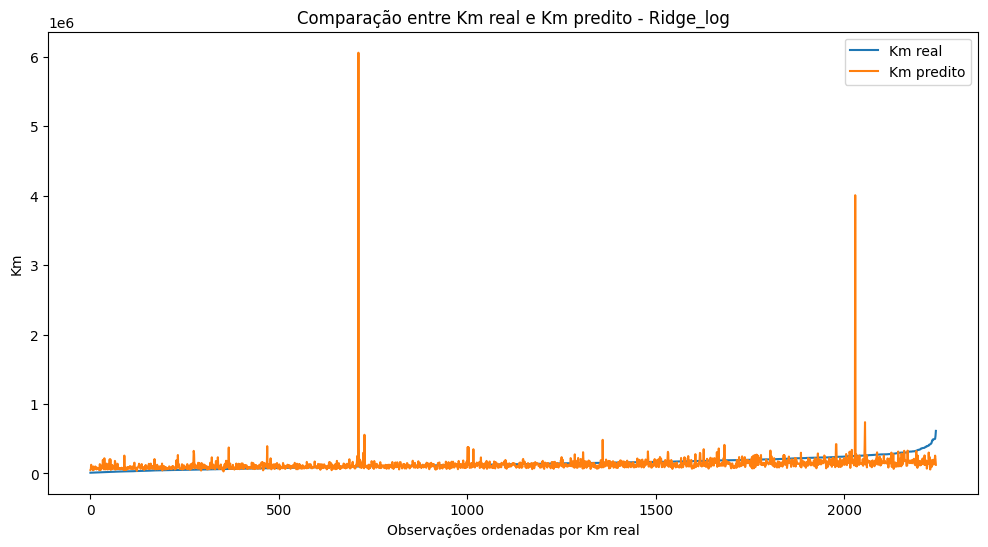


Modelo: RandomForest_log
      Km_real     Km_predito           erro       erro_abs
6602  10295.0   63910.194111   53615.194111   53615.194111
4867  10782.0   24341.833957   13559.833957   13559.833957
1718  11000.0  129565.343144  118565.343144  118565.343144
9016  11000.0  115826.406870  104826.406870  104826.406870
7919  11200.0   55070.922423   43870.922423   43870.922423
5404  11700.0   53561.825677   41861.825677   41861.825677
5266  11746.0   22303.441606   10557.441606   10557.441606
1692  12000.0   29853.784697   17853.784697   17853.784697
4575  12000.0   96170.791985   84170.791985   84170.791985
6745  12047.0   24178.223935   12131.223935   12131.223935
3367  12459.0   30699.214321   18240.214321   18240.214321
5933  12824.0   38756.691268   25932.691268   25932.691268
8566  13715.0   38945.974400   25230.974400   25230.974400
2318  13800.0  120218.042815  106418.042815  106418.042815
4442  13940.0   25972.837053   12032.837053   12032.837053
8879  13994.0   21670.092200  

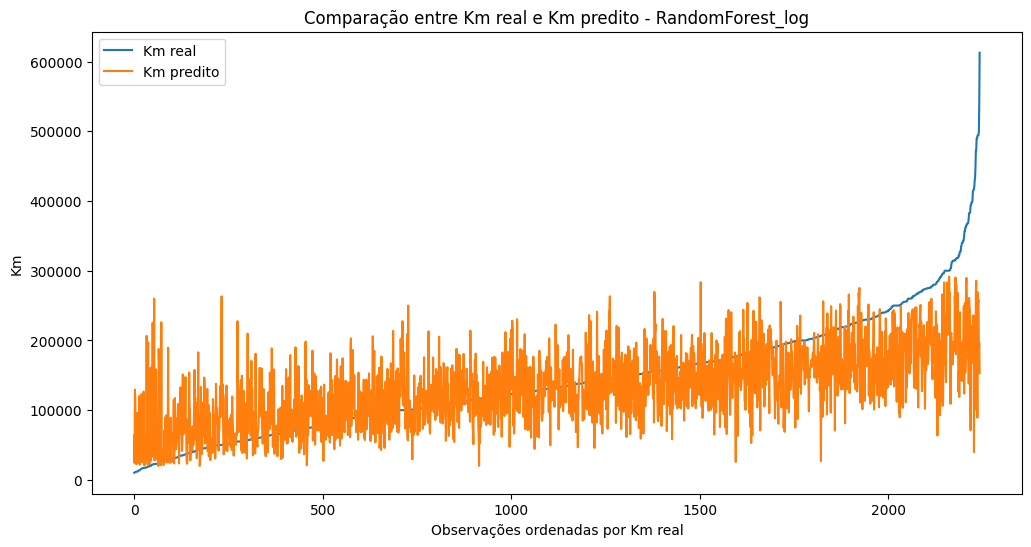


Modelo: GradientBoosting_log
      Km_real     Km_predito           erro       erro_abs
6602  10295.0   53156.944495   42861.944495   42861.944495
4867  10782.0   27398.532986   16616.532986   16616.532986
1718  11000.0  126939.012825  115939.012825  115939.012825
9016  11000.0  119903.921740  108903.921740  108903.921740
7919  11200.0   62719.467420   51519.467420   51519.467420
5404  11700.0   45420.058805   33720.058805   33720.058805
5266  11746.0   28516.387596   16770.387596   16770.387596
1692  12000.0   21440.288943    9440.288943    9440.288943
4575  12000.0  102450.655826   90450.655826   90450.655826
6745  12047.0   25116.970936   13069.970936   13069.970936
3367  12459.0   23511.686409   11052.686409   11052.686409
5933  12824.0   35523.579975   22699.579975   22699.579975
8566  13715.0   42672.825854   28957.825854   28957.825854
2318  13800.0  118929.947623  105129.947623  105129.947623
4442  13940.0   31965.754943   18025.754943   18025.754943
8879  13994.0   21539.4846

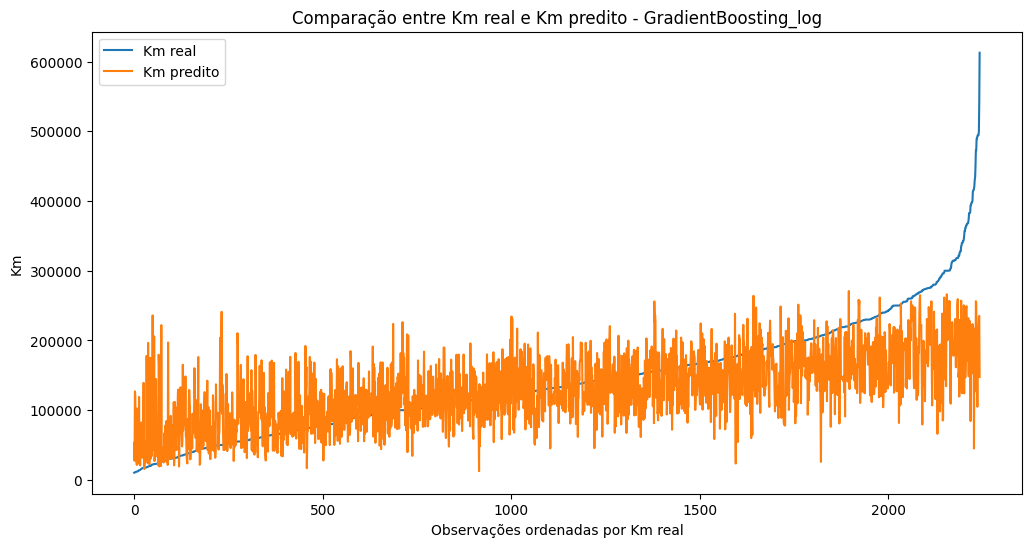


Modelo: ExtraTrees_log
      Km_real     Km_predito           erro       erro_abs
6602  10295.0   54597.153117   44302.153117   44302.153117
4867  10782.0   26248.639018   15466.639018   15466.639018
1718  11000.0  142993.591438  131993.591438  131993.591438
9016  11000.0  123345.997527  112345.997527  112345.997527
7919  11200.0   56139.556714   44939.556714   44939.556714
5404  11700.0   52830.158873   41130.158873   41130.158873
5266  11746.0   18812.004326    7066.004326    7066.004326
1692  12000.0   38034.411793   26034.411793   26034.411793
4575  12000.0   87100.002732   75100.002732   75100.002732
6745  12047.0   22601.841751   10554.841751   10554.841751
3367  12459.0   32522.214180   20063.214180   20063.214180
5933  12824.0   42505.669358   29681.669358   29681.669358
8566  13715.0   43432.870925   29717.870925   29717.870925
2318  13800.0  119295.662004  105495.662004  105495.662004
4442  13940.0   25653.518683   11713.518683   11713.518683
8879  13994.0   20334.382590    

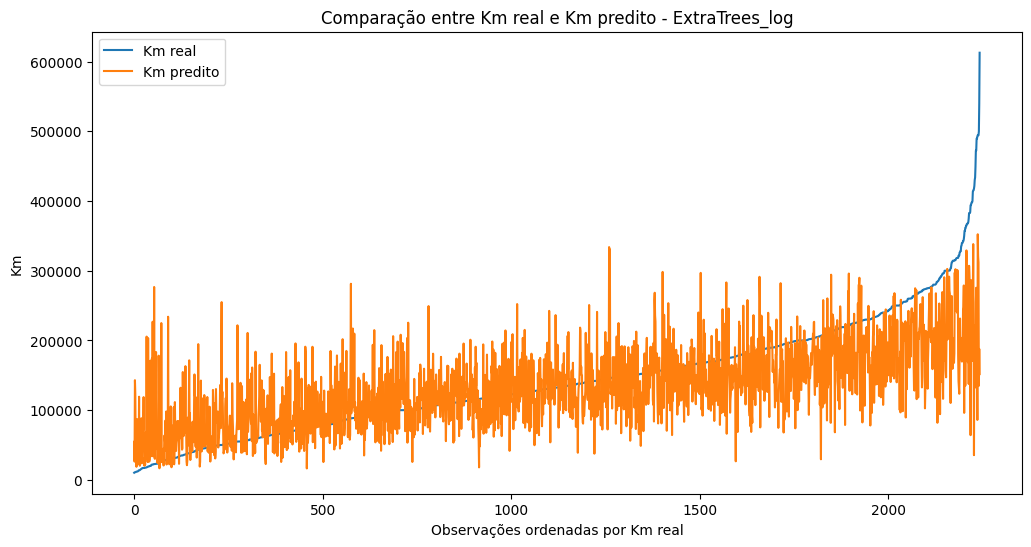


Modelo: LightGBM_L1_log
      Km_real     Km_predito           erro       erro_abs
6602  10295.0   57422.696112   47127.696112   47127.696112
4867  10782.0   32343.790044   21561.790044   21561.790044
1718  11000.0  130840.212161  119840.212161  119840.212161
9016  11000.0  111753.783423  100753.783423  100753.783423
7919  11200.0   65992.485538   54792.485538   54792.485538
5404  11700.0   46043.772527   34343.772527   34343.772527
5266  11746.0   22874.930344   11128.930344   11128.930344
1692  12000.0   27615.253647   15615.253647   15615.253647
4575  12000.0  112300.746434  100300.746434  100300.746434
6745  12047.0   30046.058730   17999.058730   17999.058730
3367  12459.0   22579.289071   10120.289071   10120.289071
5933  12824.0   37143.148604   24319.148604   24319.148604
8566  13715.0   40678.721952   26963.721952   26963.721952
2318  13800.0  124941.326235  111141.326235  111141.326235
4442  13940.0   23429.657868    9489.657868    9489.657868
8879  13994.0   17621.754316   

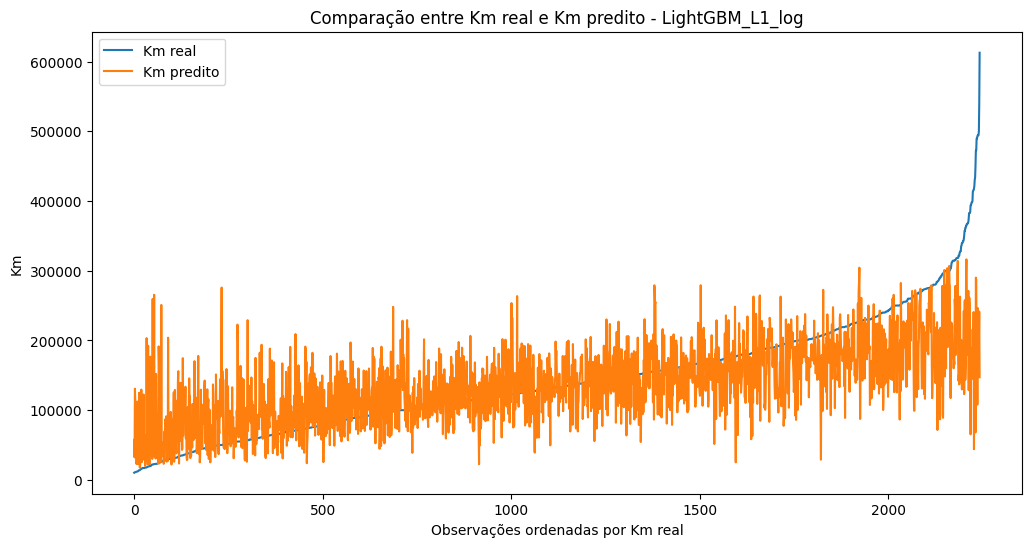


Modelo: Blend_ExtraTrees_LightGBM_log
      Km_real     Km_predito           erro       erro_abs
6602  10295.0   56069.567860   45774.567860   45774.567860
4867  10782.0   26763.243321   15981.243321   15981.243321
1718  11000.0  142435.829715  131435.829715  131435.829715
9016  11000.0  112855.476373  101855.476373  101855.476373
7919  11200.0   53655.570221   42455.570221   42455.570221
5404  11700.0   53163.201972   41463.201972   41463.201972
5266  11746.0   22603.982382   10857.982382   10857.982382
1692  12000.0   34204.330067   22204.330067   22204.330067
4575  12000.0   95734.324058   83734.324058   83734.324058
6745  12047.0   22212.309213   10165.309213   10165.309213
3367  12459.0   24301.669798   11842.669798   11842.669798
5933  12824.0   41213.171056   28389.171056   28389.171056
8566  13715.0   43370.613564   29655.613564   29655.613564
2318  13800.0  124499.477414  110699.477414  110699.477414
4442  13940.0   25719.944592   11779.944592   11779.944592
8879  13994.0   2

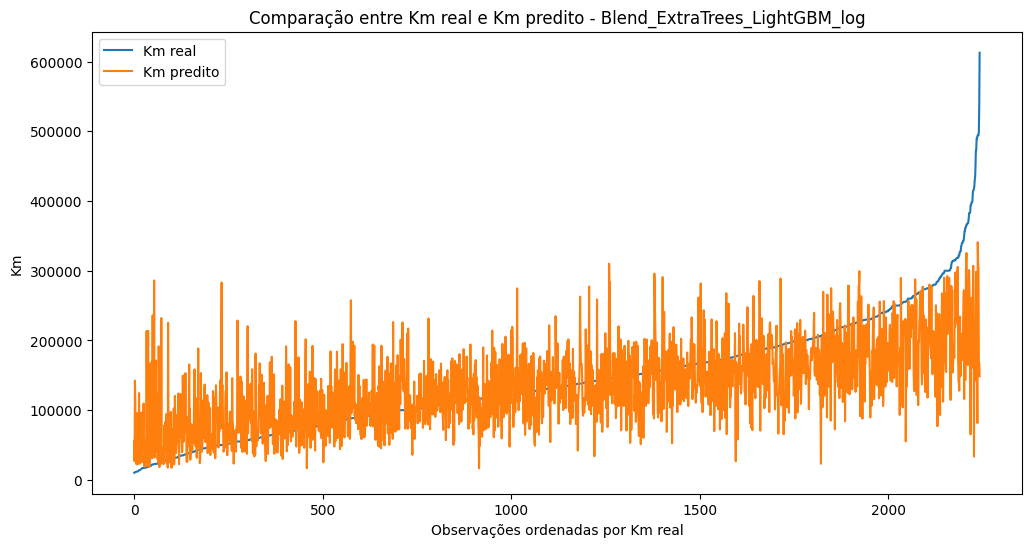


Modelo: XGBoost_log
      Km_real     Km_predito           erro       erro_abs
6602  10295.0   63177.511719   52882.511719   52882.511719
4867  10782.0   36767.851562   25985.851562   25985.851562
1718  11000.0  123735.453125  112735.453125  112735.453125
9016  11000.0  129326.773438  118326.773438  118326.773438
7919  11200.0   66681.031250   55481.031250   55481.031250
5404  11700.0   52876.207031   41176.207031   41176.207031
5266  11746.0   32018.541016   20272.541016   20272.541016
1692  12000.0   35600.890625   23600.890625   23600.890625
4575  12000.0  123928.546875  111928.546875  111928.546875
6745  12047.0   49232.843750   37185.843750   37185.843750
3367  12459.0   38062.656250   25603.656250   25603.656250
5933  12824.0   41524.015625   28700.015625   28700.015625
8566  13715.0   41397.800781   27682.800781   27682.800781
2318  13800.0  126103.398438  112303.398438  112303.398438
4442  13940.0   34071.500000   20131.500000   20131.500000
8879  13994.0   33140.281250   1914

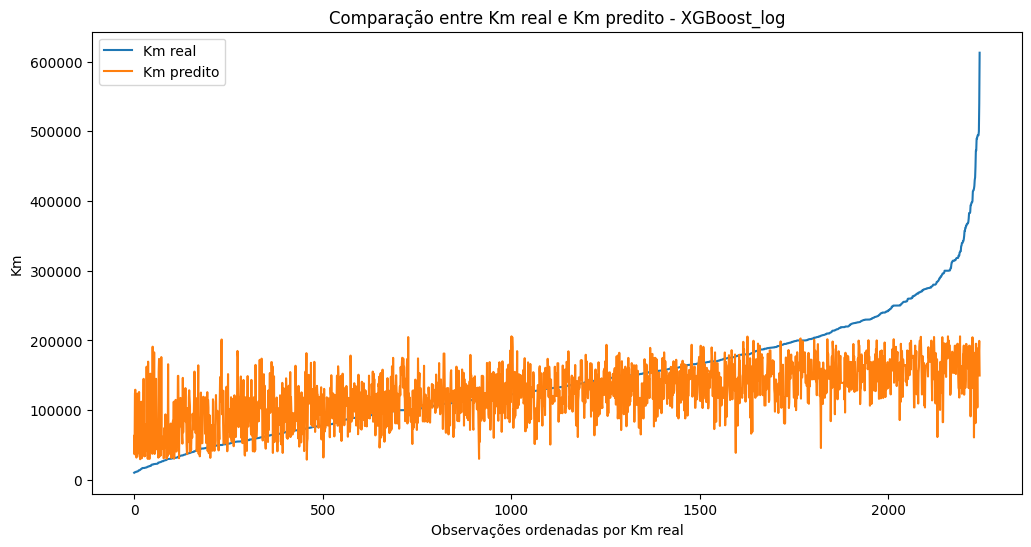


Modelo: KNN_log
      Km_real     Km_predito           erro       erro_abs
6602  10295.0   95582.689045   85287.689045   85287.689045
4867  10782.0   91301.065818   80519.065818   80519.065818
1718  11000.0   82030.392628   71030.392628   71030.392628
9016  11000.0   99679.838102   88679.838102   88679.838102
7919  11200.0   97046.449192   85846.449192   85846.449192
5404  11700.0  105021.702836   93321.702836   93321.702836
5266  11746.0   52163.393591   40417.393591   40417.393591
1692  12000.0   71616.225573   59616.225573   59616.225573
4575  12000.0  150755.904194  138755.904194  138755.904194
6745  12047.0   87856.449470   75809.449470   75809.449470
3367  12459.0  134943.194654  122484.194654  122484.194654
5933  12824.0  129248.636238  116424.636238  116424.636238
8566  13715.0   87617.172014   73902.172014   73902.172014
2318  13800.0  117671.371937  103871.371937  103871.371937
4442  13940.0   81909.940229   67969.940229   67969.940229
8879  13994.0  229777.900142  215783.90

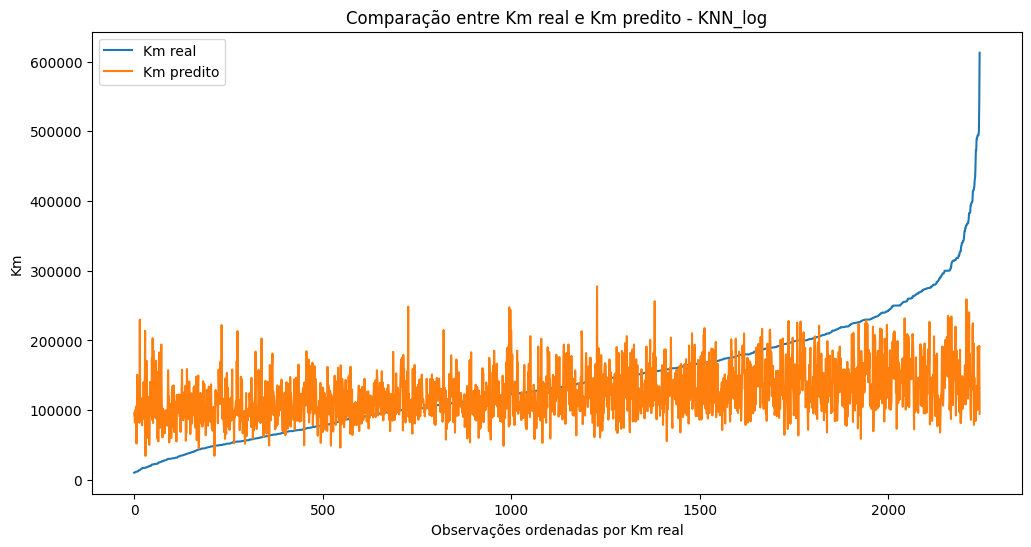


Modelo: SVR_log
      Km_real     Km_predito           erro       erro_abs
6602  10295.0   80084.676662   69789.676662   69789.676662
4867  10782.0   61165.882040   50383.882040   50383.882040
1718  11000.0  120280.102120  109280.102120  109280.102120
9016  11000.0  119007.376430  108007.376430  108007.376430
7919  11200.0  105608.199697   94408.199697   94408.199697
5404  11700.0   67182.054198   55482.054198   55482.054198
5266  11746.0   53090.279537   41344.279537   41344.279537
1692  12000.0   82433.223104   70433.223104   70433.223104
4575  12000.0  127051.534557  115051.534557  115051.534557
6745  12047.0   72629.790982   60582.790982   60582.790982
3367  12459.0   67605.388602   55146.388602   55146.388602
5933  12824.0   76903.306209   64079.306209   64079.306209
8566  13715.0   62525.660826   48810.660826   48810.660826
2318  13800.0  131920.270139  118120.270139  118120.270139
4442  13940.0   58619.008066   44679.008066   44679.008066
8879  13994.0   74516.314692   60522.31

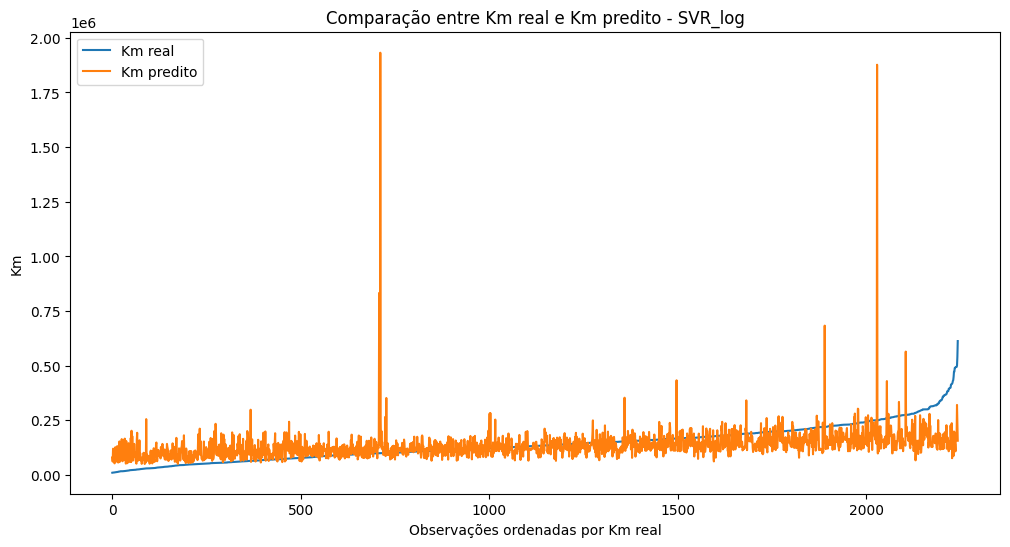

In [165]:
# =========================================================
# 5. Mostrar tabela e gráfico para cada modelo
# =========================================================
for nome_modelo, resultado_km in resultados_predicoes.items():
    print(f"\n{'='*60}")
    print(f"Modelo: {nome_modelo}")
    print(f"{'='*60}")
    print(resultado_km.head(20))

    resultado_plot = resultado_km.reset_index(drop=True)

    plt.figure(figsize=(12, 6))
    plt.plot(resultado_plot["Km_real"].values, label="Km real")
    plt.plot(resultado_plot["Km_predito"].values, label="Km predito")
    plt.xlabel("Observações ordenadas por Km real")
    plt.ylabel("Km")
    plt.title(f"Comparação entre Km real e Km predito - {nome_modelo}")
    plt.legend()
    plt.show()

In [166]:
# Treinar novamente, agora com todos os registros que tem Km conhecido,
# usando o melhor modelo escolhido pelo grid search.
km_faltante_antes_predicao = df["Km"].isna()
df["Km_imputado"] = km_faltante_antes_predicao.astype(int)

train_km_full = df[df["Km"].notna()].copy()
pred_km = df[km_faltante_antes_predicao].copy()

X_train_full = train_km_full[features_km]
y_train_full = train_km_full["Km"]

melhor_nome_km = df_metricas.iloc[0]["Modelo"]
model_km_final = clone(melhores_modelos[melhor_nome_km])
model_km_final.fit(X_train_full, y_train_full)

if len(pred_km) > 0:
    km_previsto = np.clip(model_km_final.predict(pred_km[features_km]), 0, None)
    df.loc[pred_km.index, "Km"] = km_previsto

# Atualizar a feature derivada depois da imputacao.
df["Km_por_ano"] = df["Km"] / df["Idade"]

print("Modelo usado para imputar Km:", melhor_nome_km)
print("Faltantes restantes em Km:", df["Km"].isna().sum())
print("Registros com Km imputado:", df["Km_imputado"].sum())

Modelo usado para imputar Km: LightGBM_L1_log
Faltantes restantes em Km: 0
Registros com Km imputado: 1611


c:\Users\pertile\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [167]:
#df.to_csv('database/test_tratado.csv', index=False)
df.to_csv('database/train_mod_tratado.csv', index=False)